In [1]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. 원본 데이터 불러오기
# ============================================================

DATA_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data\raw\fraudTrain.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

print("데이터 크기:", df.shape)


# ============================================================
# 2. 통계 요약 대상 수치형 변수 선정
# ============================================================

# 숫자로 저장됐지만 연속형 변수로 해석하면 안 되는 컬럼
exclude_columns = {
    "Unnamed: 0",   # 행 번호
    "cc_num",       # 카드 식별자
    "unix_time",    # 시간 식별값
    "zip",          # 우편번호
    "is_fraud",     # 평가용 타깃
}

numeric_columns = [
    col for col in df.select_dtypes(include="number").columns
    if col not in exclude_columns
]

print("\n통계 요약 대상 변수:")
print(numeric_columns)


# ============================================================
# 3. 기초 통계 요약표 생성
# ============================================================

numeric_summary = pd.DataFrame({
    "valid_count": df[numeric_columns].count(),
    "missing_count": df[numeric_columns].isna().sum(),
    "missing_rate_pct": df[numeric_columns].isna().mean() * 100,

    "mean": df[numeric_columns].mean(),
    "std": df[numeric_columns].std(),

    "min": df[numeric_columns].min(),
    "q1_25pct": df[numeric_columns].quantile(0.25),
    "median_50pct": df[numeric_columns].median(),
    "q3_75pct": df[numeric_columns].quantile(0.75),

    "p95": df[numeric_columns].quantile(0.95),
    "p99": df[numeric_columns].quantile(0.99),
    "max": df[numeric_columns].max(),

    "skewness": df[numeric_columns].skew(),
}).reset_index(names="variable")


# 소수점 정리
numeric_summary = numeric_summary.round({
    "missing_rate_pct": 4,
    "mean": 4,
    "std": 4,
    "min": 4,
    "q1_25pct": 4,
    "median_50pct": 4,
    "q3_75pct": 4,
    "p95": 4,
    "p99": 4,
    "max": 4,
    "skewness": 4,
})

print("\n" + "=" * 100)
print("수치형 변수 기초 통계 요약")
print("=" * 100)

display(numeric_summary)


# ============================================================
# 4. 결과 저장
# ============================================================

OUTPUT_PATH = DATA_PATH.parent / "fraudTrain_numeric_summary.csv"

numeric_summary.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 통계 요약 저장 완료")
print("저장 경로:", OUTPUT_PATH)

데이터 크기: (1296675, 23)

통계 요약 대상 변수:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']

수치형 변수 기초 통계 요약


,variable,valid_count,missing_count,missing_rate_pct,mean,std,min,q1_25pct,median_50pct,q3_75pct,p95,p99,max,skewness
0,amt,1296675,0,0.0,70.3510,160.3160,1.0000,9.6500,47.5200,83.1400,196.3100,5.459926e+02,2.894890e+04,42.2779
1,lat,1296675,0,0.0,38.5376,5.0758,20.0271,34.6205,39.3543,41.9404,45.8433,4.847860e+01,6.669330e+01,-0.1860
2,long,1296675,0,0.0,-90.2263,13.7591,-165.6723,-96.7980,-87.4769,-80.1580,-73.5112,-7.034570e+01,-6.795030e+01,-1.1501
3,city_pop,1296675,0,0.0,88824.4406,301956.3607,23.0000,743.0000,2456.0000,20328.0000,525713.0000,1.577385e+06,2.906700e+06,5.5939
4,merch_lat,1296675,0,0.0,38.5373,5.1098,19.0278,34.7336,39.3657,41.9572,46.0035,4.857790e+01,6.751030e+01,-0.1819
5,merch_long,1296675,0,0.0,-90.2265,13.7711,-166.6712,-96.8973,-87.4384,-80.2368,-73.3542,-7.038500e+01,-6.695090e+01,-1.1470



✅ 통계 요약 저장 완료
저장 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain_numeric_summary.csv


C:\Users\splen\AppData\Local\Temp\ipykernel_45500\3831900853.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


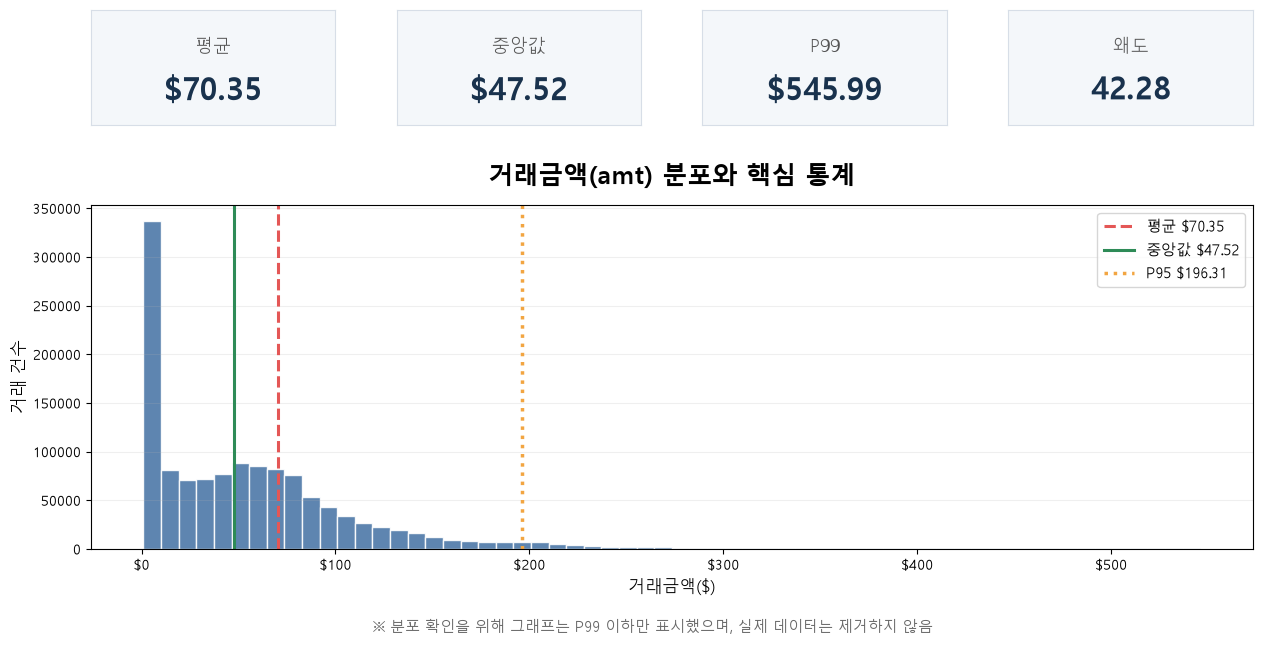

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# amt 핵심 통계 계산
# ============================================================

amt = df["amt"].dropna()

amt_mean = amt.mean()
amt_median = amt.median()
amt_std = amt.std()
amt_q1 = amt.quantile(0.25)
amt_q3 = amt.quantile(0.75)
amt_p95 = amt.quantile(0.95)
amt_p99 = amt.quantile(0.99)
amt_max = amt.max()
amt_skew = amt.skew()

# 시각화에서는 P99까지만 표시
amt_visual = amt[amt <= amt_p99]


# ============================================================
# 시각화
# ============================================================

fig = plt.figure(figsize=(15, 7))
grid = fig.add_gridspec(
    2, 4,
    height_ratios=[1, 3],
    hspace=0.35,
    wspace=0.25
)

# 상단 통계 카드
card_values = [
    ("평균", f"${amt_mean:,.2f}"),
    ("중앙값", f"${amt_median:,.2f}"),
    ("P99", f"${amt_p99:,.2f}"),
    ("왜도", f"{amt_skew:,.2f}")
]

for i, (label, value) in enumerate(card_values):
    ax = fig.add_subplot(grid[0, i])
    ax.set_facecolor("#F4F7FA")

    ax.text(
        0.5, 0.68, label,
        ha="center", va="center",
        fontsize=13,
        color="#555555"
    )

    ax.text(
        0.5, 0.30, value,
        ha="center", va="center",
        fontsize=22,
        fontweight="bold",
        color="#19324D"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_color("#D7DEE7")


# 하단 히스토그램
ax = fig.add_subplot(grid[1, :])

ax.hist(
    amt_visual,
    bins=60,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.9
)

ax.axvline(
    amt_mean,
    color="#E45756",
    linestyle="--",
    linewidth=2.2,
    label=f"평균 ${amt_mean:,.2f}"
)

ax.axvline(
    amt_median,
    color="#2E8B57",
    linestyle="-",
    linewidth=2.2,
    label=f"중앙값 ${amt_median:,.2f}"
)

ax.axvline(
    amt_p95,
    color="#F2A541",
    linestyle=":",
    linewidth=2.5,
    label=f"P95 ${amt_p95:,.2f}"
)

ax.set_title(
    "거래금액(amt) 분포와 핵심 통계",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("거래금액($)", fontsize=12)
ax.set_ylabel("거래 건수", fontsize=12)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    "※ 분포 확인을 위해 그래프는 P99 이하만 표시했으며, 실제 데이터는 제거하지 않음",
    fontsize=11,
    color="#666666",
    y=0.01
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

C:\Users\splen\AppData\Local\Temp\ipykernel_45500\2745467237.py:54: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(amt, **box_style)
C:\Users\splen\AppData\Local\Temp\ipykernel_45500\2745467237.py:64: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(
Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub313' [U+b313], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac12' [U+ac12], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub313' [U+b313], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac12' [U+ac

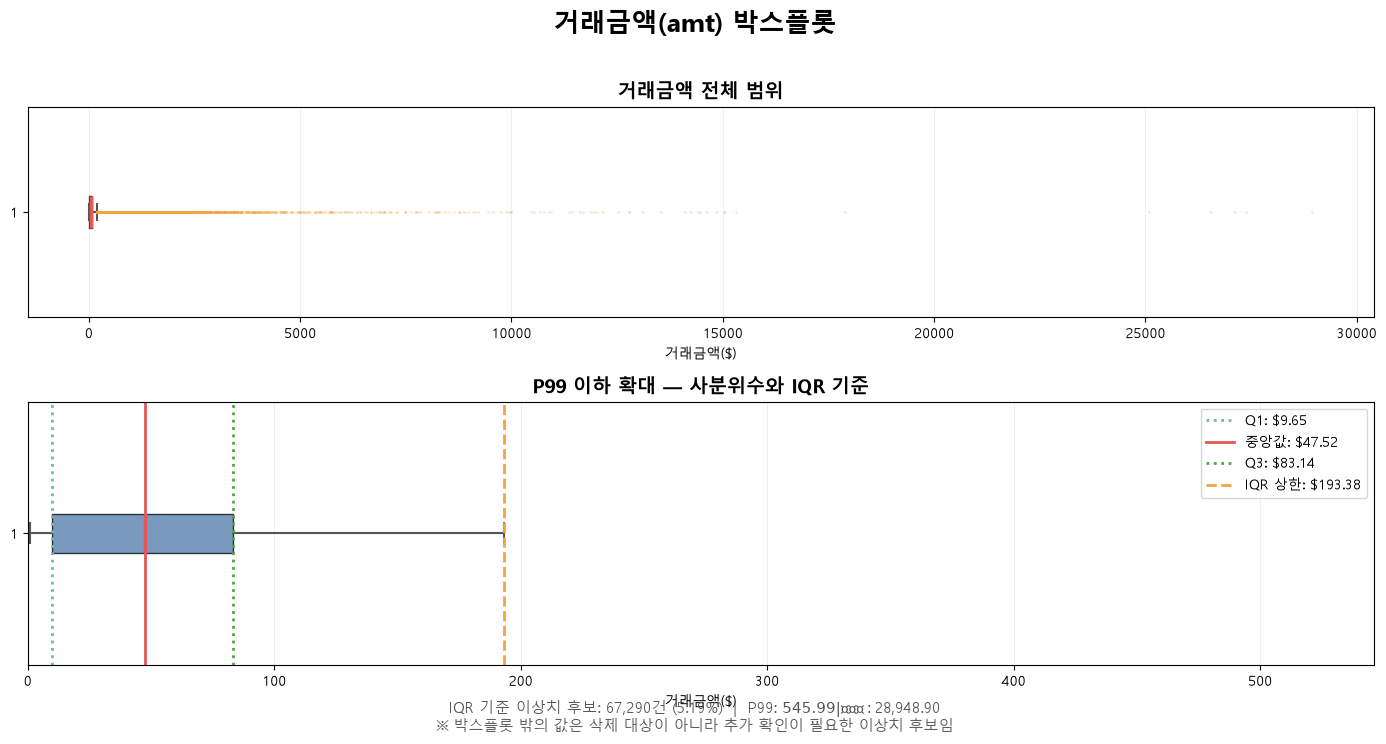

In [3]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 거래금액 통계값
# ============================================================

amt = df["amt"].dropna()

q1 = amt.quantile(0.25)
median = amt.median()
q3 = amt.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

p99 = amt.quantile(0.99)
max_value = amt.max()

outlier_count = ((amt < lower_bound) | (amt > upper_bound)).sum()
outlier_rate = outlier_count / len(amt) * 100


# ============================================================
# 박스플롯 시각화
# ============================================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    height_ratios=[1, 1.25]
)

box_style = dict(
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#4C78A8", alpha=0.75),
    medianprops=dict(color="#E45756", linewidth=2.5),
    whiskerprops=dict(color="#555555", linewidth=1.5),
    capprops=dict(color="#555555", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="#F2A541",
        markeredgecolor="none",
        markersize=2,
        alpha=0.25
    )
)

# ① 전체 범위
axes[0].boxplot(amt, **box_style)
axes[0].set_title(
    "거래금액 전체 범위",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("거래금액($)")
axes[0].grid(axis="x", alpha=0.2)

# ② P99 확대
axes[1].boxplot(
    amt,
    showfliers=False,
    **{
        key: value
        for key, value in box_style.items()
        if key != "flierprops"
    }
)

axes[1].set_xlim(0, p99)
axes[1].axvline(
    q1,
    color="#72B7B2",
    linestyle=":",
    linewidth=2,
    label=f"Q1: ${q1:,.2f}"
)
axes[1].axvline(
    median,
    color="#E45756",
    linestyle="-",
    linewidth=2,
    label=f"중앙값: ${median:,.2f}"
)
axes[1].axvline(
    q3,
    color="#54A24B",
    linestyle=":",
    linewidth=2,
    label=f"Q3: ${q3:,.2f}"
)
axes[1].axvline(
    upper_bound,
    color="#F2A541",
    linestyle="--",
    linewidth=2,
    label=f"IQR 상한: ${upper_bound:,.2f}"
)

axes[1].set_title(
    "P99 이하 확대 — 사분위수와 IQR 기준",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("거래금액($)")
axes[1].grid(axis="x", alpha=0.2)
axes[1].legend(loc="upper right")

fig.suptitle(
    "거래금액(amt) 박스플롯",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    (
        f"IQR 기준 이상치 후보: {outlier_count:,}건 "
        f"({outlier_rate:.2f}%)  |  "
        f"P99: ${p99:,.2f}  |  최댓값: ${max_value:,.2f}\n"
        "※ 박스플롯 밖의 값은 삭제 대상이 아니라 추가 확인이 필요한 이상치 후보임"
    ),
    ha="center",
    fontsize=11,
    color="#555555"
)

plt.tight_layout()
plt.show()

P95: $196.31
P99: $545.99
최댓값: $28,948.90
상위 5% 거래: 64,835건
P95~P99 거래: 51,868건
P99 이상 거래: 12,967건


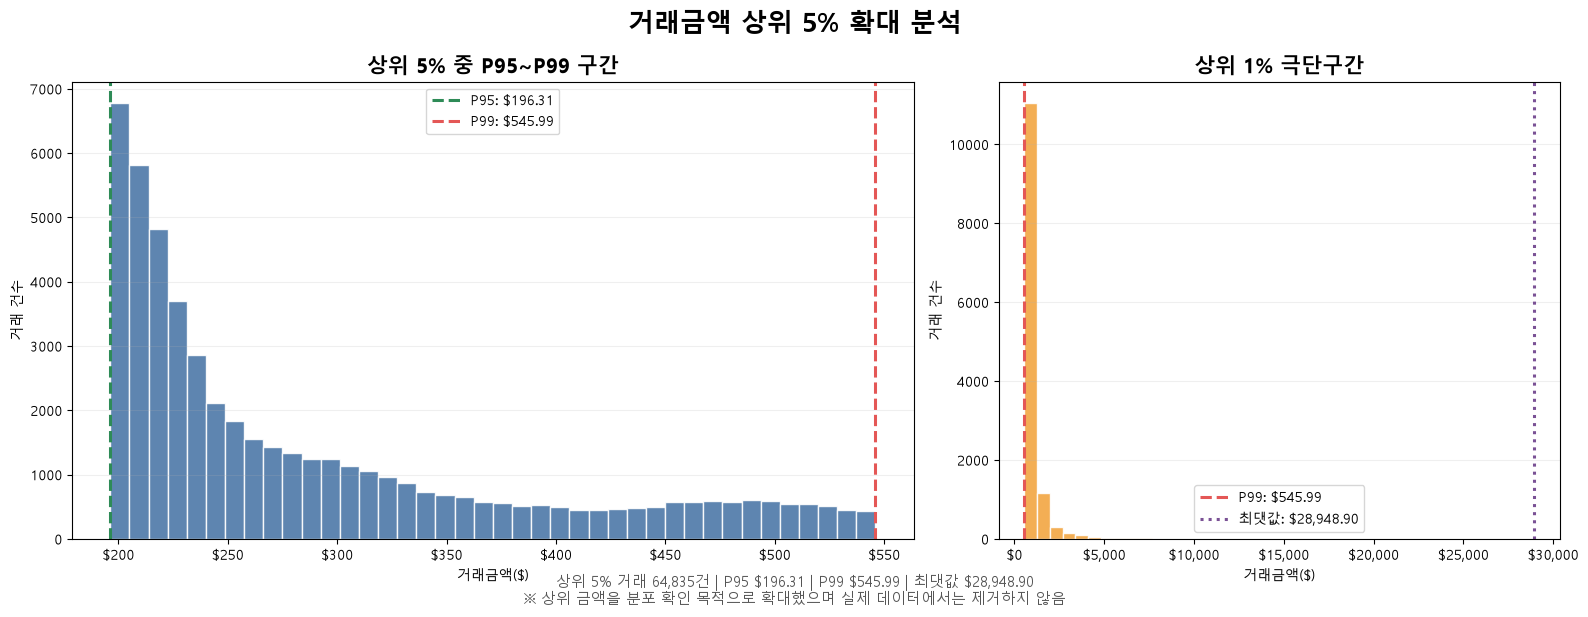

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 거래금액 상위 5% 추출
# ============================================================

amt = df["amt"].dropna()

p95 = amt.quantile(0.95)
p99 = amt.quantile(0.99)
max_value = amt.max()

top_5 = amt[amt >= p95]
p95_to_p99 = amt[(amt >= p95) & (amt < p99)]
top_1 = amt[amt >= p99]

print(f"P95: ${p95:,.2f}")
print(f"P99: ${p99:,.2f}")
print(f"최댓값: ${max_value:,.2f}")
print(f"상위 5% 거래: {len(top_5):,}건")
print(f"P95~P99 거래: {len(p95_to_p99):,}건")
print(f"P99 이상 거래: {len(top_1):,}건")


# ============================================================
# 상위 5% 거래금액 확대 시각화
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.5, 1]}
)

# ① P95 이상 ~ P99 미만
axes[0].hist(
    p95_to_p99,
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.9
)

axes[0].axvline(
    p95,
    color="#2E8B57",
    linestyle="--",
    linewidth=2.2,
    label=f"P95: ${p95:,.2f}"
)

axes[0].axvline(
    p99,
    color="#E45756",
    linestyle="--",
    linewidth=2.2,
    label=f"P99: ${p99:,.2f}"
)

axes[0].set_title(
    "상위 5% 중 P95~P99 구간",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_xlabel("거래금액($)")
axes[0].set_ylabel("거래 건수")
axes[0].xaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)
axes[0].grid(axis="y", alpha=0.2)
axes[0].legend()


# ② P99 이상 극단구간
axes[1].hist(
    top_1,
    bins=40,
    color="#F2A541",
    edgecolor="white",
    alpha=0.9
)

axes[1].axvline(
    p99,
    color="#E45756",
    linestyle="--",
    linewidth=2.2,
    label=f"P99: ${p99:,.2f}"
)

axes[1].axvline(
    max_value,
    color="#7A5195",
    linestyle=":",
    linewidth=2.2,
    label=f"최댓값: ${max_value:,.2f}"
)

axes[1].set_title(
    "상위 1% 극단구간",
    fontsize=15,
    fontweight="bold"
)
axes[1].set_xlabel("거래금액($)")
axes[1].set_ylabel("거래 건수")
axes[1].xaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()


fig.suptitle(
    "거래금액 상위 5% 확대 분석",
    fontsize=19,
    fontweight="bold"
)

fig.text(
    0.5,
    -0.01,
    (
        f"상위 5% 거래 {len(top_5):,}건 | "
        f"P95 ${p95:,.2f} | P99 ${p99:,.2f} | "
        f"최댓값 ${max_value:,.2f}\n"
        "※ 상위 금액을 분포 확인 목적으로 확대했으며 실제 데이터에서는 제거하지 않음"
    ),
    ha="center",
    fontsize=11,
    color="#555555"
)

plt.tight_layout()
plt.show()

C:\Users\splen\AppData\Local\Temp\ipykernel_45500\845664938.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


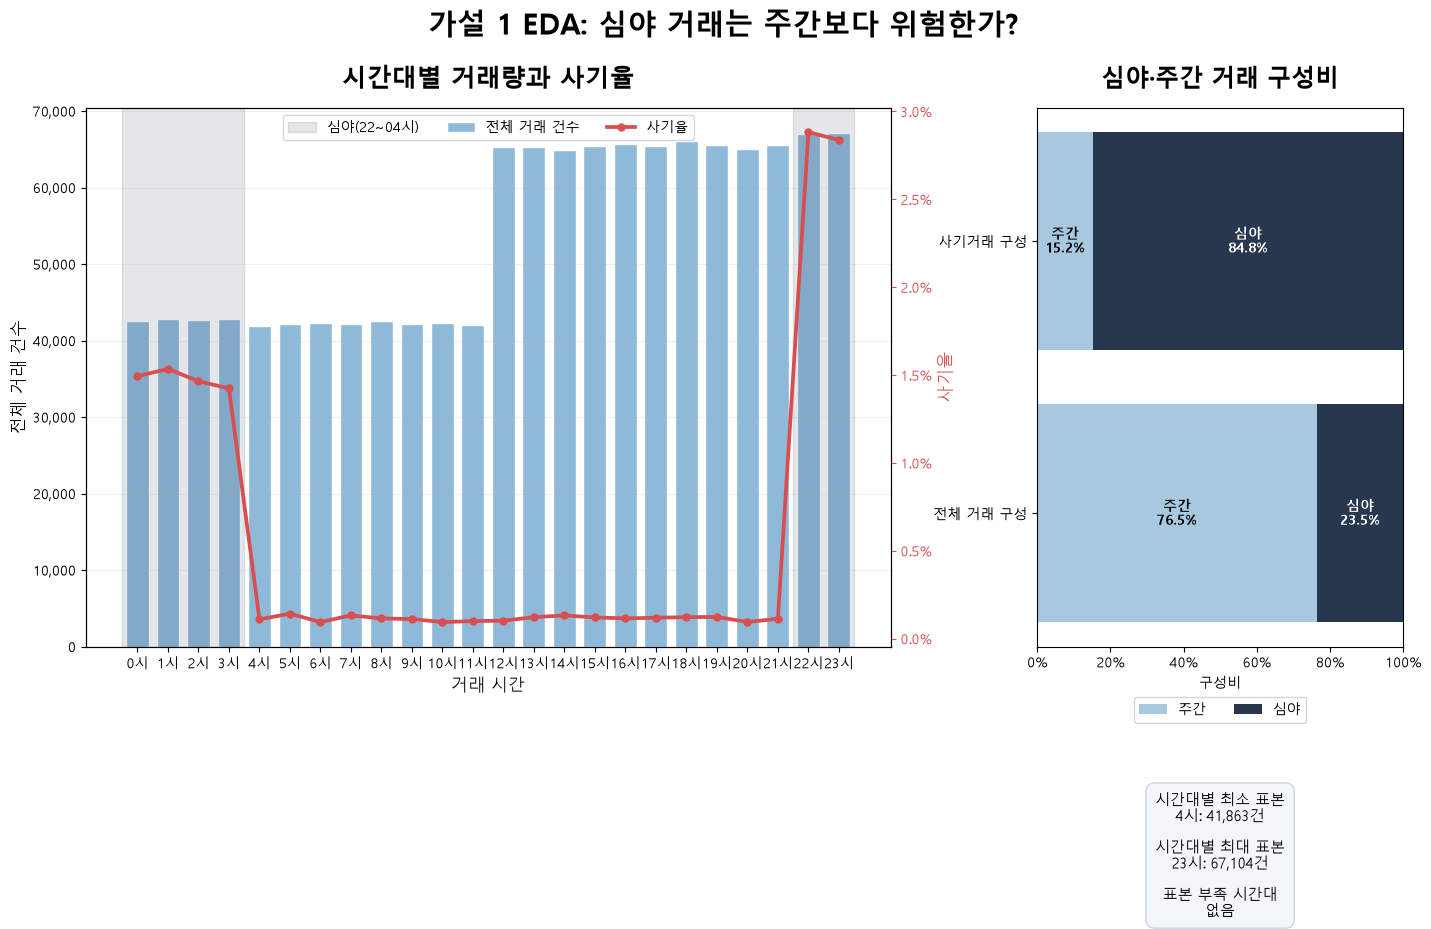


✅ 시각화 저장 완료
저장 경로: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\hypothesis1_time_eda.png

시간대별 EDA 요약


,trans_hour,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
0,0,42502,635,0.014940,1.494047
1,1,42869,658,0.015349,1.534909
2,2,42656,625,0.014652,1.465210
3,3,42769,609,0.014239,1.423929
4,4,41863,46,0.001099,0.109882
5,5,42171,60,0.001423,0.142278
6,6,42300,40,0.000946,0.094563
7,7,42203,56,0.001327,0.132692
8,8,42505,49,0.001153,0.115281
9,9,42185,47,0.001114,0.111414


,time_group,transaction_count,fraud_count,transaction_share_pct,fraud_share_pct,fraud_rate_pct
0,주간(04~22시),991793,1144,76.4874,15.2411,0.1153
1,심야(22~04시),304882,6362,23.5126,84.7589,2.0867


시간대별 최소 거래 수: 4시 41,863건
시간대별 최대 거래 수: 23시 67,104건
표본 부족 여부: 모든 시간대에 충분한 거래 표본이 존재


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ============================================================
# 1. 데이터 준비
# ============================================================

# df가 없다면 아래 경로에서 불러오기
if "df" not in globals():
    DATA_PATH = Path(
        r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
        r"\Fraud-FDS-Project\data\raw\fraudTrain.csv"
    )
    df = pd.read_csv(DATA_PATH, low_memory=False)

# 거래일시 자료형 변환
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

# 시간 추출
df["trans_hour"] = df["trans_date_trans_time"].dt.hour

# 심야: 22·23·0·1·2·3시
df["time_group"] = np.where(
    (df["trans_hour"] >= 22) | (df["trans_hour"] < 4),
    "심야(22~04시)",
    "주간(04~22시)"
)


# ============================================================
# 2. 시간대별 통계 계산
# ============================================================

hourly_summary = (
    df.groupby("trans_hour")
      .agg(
          transaction_count=("is_fraud", "size"),
          fraud_count=("is_fraud", "sum"),
          fraud_rate=("is_fraud", "mean")
      )
      .reindex(range(24), fill_value=0)
      .reset_index()
)

hourly_summary["fraud_rate_pct"] = (
    hourly_summary["fraud_rate"] * 100
)


# ============================================================
# 3. 심야·주간 구성비 계산
# ============================================================

time_group_summary = (
    df.groupby("time_group")
      .agg(
          transaction_count=("is_fraud", "size"),
          fraud_count=("is_fraud", "sum")
      )
      .reindex(["주간(04~22시)", "심야(22~04시)"])
      .reset_index()
)

time_group_summary["transaction_share_pct"] = (
    time_group_summary["transaction_count"]
    / time_group_summary["transaction_count"].sum()
    * 100
)

time_group_summary["fraud_share_pct"] = (
    time_group_summary["fraud_count"]
    / time_group_summary["fraud_count"].sum()
    * 100
)

time_group_summary["fraud_rate_pct"] = (
    time_group_summary["fraud_count"]
    / time_group_summary["transaction_count"]
    * 100
)


# ============================================================
# 4. 표본 수 점검
# ============================================================

min_row = hourly_summary.loc[
    hourly_summary["transaction_count"].idxmin()
]

max_row = hourly_summary.loc[
    hourly_summary["transaction_count"].idxmax()
]

min_hour = int(min_row["trans_hour"])
min_count = int(min_row["transaction_count"])
max_hour = int(max_row["trans_hour"])
max_count = int(max_row["transaction_count"])

# 전체 거래의 1%를 임의의 표본 부족 점검 기준으로 사용
sample_reference = len(df) * 0.01
sample_shortage = min_count < sample_reference


# ============================================================
# 5. 발표용 통합 시각화
# ============================================================

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure(figsize=(17, 7))
grid = fig.add_gridspec(
    1, 2,
    width_ratios=[2.2, 1],
    wspace=0.25
)

# ------------------------------------------------------------
# 왼쪽: 시간대별 거래 건수 + 사기율
# ------------------------------------------------------------

ax1 = fig.add_subplot(grid[0, 0])
ax2 = ax1.twinx()

hours = hourly_summary["trans_hour"]
transaction_counts = hourly_summary["transaction_count"]
fraud_rates = hourly_summary["fraud_rate_pct"]

# 전체 거래 건수
bars = ax1.bar(
    hours,
    transaction_counts,
    width=0.75,
    color="#8FB9D9",
    edgecolor="white",
    label="전체 거래 건수"
)

# 심야 시간 음영
ax1.axvspan(
    -0.5, 3.5,
    color="#27374D",
    alpha=0.12
)
ax1.axvspan(
    21.5, 23.5,
    color="#27374D",
    alpha=0.12,
    label="심야(22~04시)"
)

# 사기율
ax2.plot(
    hours,
    fraud_rates,
    color="#D94F4F",
    marker="o",
    linewidth=2.7,
    markersize=5,
    label="사기율"
)

ax1.set_title(
    "시간대별 거래량과 사기율",
    fontsize=18,
    fontweight="bold",
    pad=15
)
ax1.set_xlabel("거래 시간", fontsize=12)
ax1.set_ylabel("전체 거래 건수", fontsize=12)
ax2.set_ylabel("사기율", fontsize=12, color="#D94F4F")

ax1.set_xticks(range(24))
ax1.set_xticklabels([f"{h}시" for h in range(24)])
ax1.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)
ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100, decimals=1)
)

ax1.grid(axis="y", alpha=0.2)
ax2.tick_params(axis="y", colors="#D94F4F")

# 범례 합치기
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    frameon=True
)


# ------------------------------------------------------------
# 오른쪽: 심야·주간 구성비
# ------------------------------------------------------------

ax3 = fig.add_subplot(grid[0, 1])

day_transaction_share = time_group_summary.loc[
    time_group_summary["time_group"] == "주간(04~22시)",
    "transaction_share_pct"
].iloc[0]

night_transaction_share = time_group_summary.loc[
    time_group_summary["time_group"] == "심야(22~04시)",
    "transaction_share_pct"
].iloc[0]

day_fraud_share = time_group_summary.loc[
    time_group_summary["time_group"] == "주간(04~22시)",
    "fraud_share_pct"
].iloc[0]

night_fraud_share = time_group_summary.loc[
    time_group_summary["time_group"] == "심야(22~04시)",
    "fraud_share_pct"
].iloc[0]

# 100% 누적 막대
ax3.barh(
    ["전체 거래 구성", "사기거래 구성"],
    [day_transaction_share, day_fraud_share],
    color="#A8C8E0",
    label="주간"
)

ax3.barh(
    ["전체 거래 구성", "사기거래 구성"],
    [night_transaction_share, night_fraud_share],
    left=[day_transaction_share, day_fraud_share],
    color="#27374D",
    label="심야"
)

# 구성비 라벨
ax3.text(
    day_transaction_share / 2,
    0,
    f"주간\n{day_transaction_share:.1f}%",
    ha="center",
    va="center",
    fontweight="bold"
)

ax3.text(
    day_transaction_share + night_transaction_share / 2,
    0,
    f"심야\n{night_transaction_share:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax3.text(
    day_fraud_share / 2,
    1,
    f"주간\n{day_fraud_share:.1f}%",
    ha="center",
    va="center",
    fontweight="bold"
)

ax3.text(
    day_fraud_share + night_fraud_share / 2,
    1,
    f"심야\n{night_fraud_share:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

ax3.set_xlim(0, 100)
ax3.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100)
)

ax3.set_title(
    "심야·주간 거래 구성비",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax3.set_xlabel("구성비")
ax3.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2
)

# 표본 수 점검 문구
sample_message = (
    f"시간대별 최소 표본\n"
    f"{min_hour}시: {min_count:,}건\n\n"
    f"시간대별 최대 표본\n"
    f"{max_hour}시: {max_count:,}건\n\n"
    f"표본 부족 시간대\n"
    f"{'있음' if sample_shortage else '없음'}"
)

ax3.text(
    0.5,
    -0.27,
    sample_message,
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#F4F7FA",
        edgecolor="#CBD5E1"
    )
)

fig.suptitle(
    "가설 1 EDA: 심야 거래는 주간보다 위험한가?",
    fontsize=21,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# 이미지 저장
OUTPUT_PATH = Path.cwd() / "hypothesis1_time_eda.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ 시각화 저장 완료")
print("저장 경로:", OUTPUT_PATH)


# ============================================================
# 6. 발표용 요약 출력
# ============================================================

print("\n" + "=" * 70)
print("시간대별 EDA 요약")
print("=" * 70)

display(hourly_summary)
display(time_group_summary.round(4))

print(f"시간대별 최소 거래 수: {min_hour}시 {min_count:,}건")
print(f"시간대별 최대 거래 수: {max_hour}시 {max_count:,}건")
print(
    "표본 부족 여부:",
    "일부 시간대 점검 필요" if sample_shortage
    else "모든 시간대에 충분한 거래 표본이 존재"
)

전체 심야 거래: 304,882건
심야 정상거래: 298,520건 (97.91%)
심야 사기거래: 6,362건 (2.09%)


C:\Users\splen\AppData\Local\Temp\ipykernel_45500\450979232.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


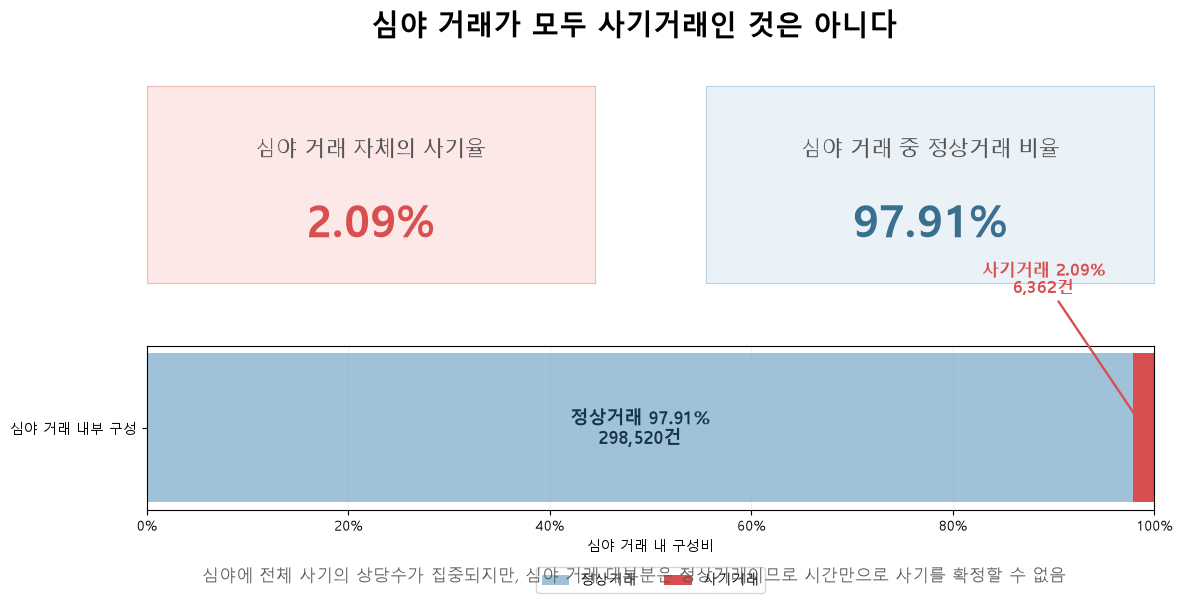


✅ 이미지 저장 완료
저장 경로: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\night_transaction_fraud_normal_share.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 심야 거래 추출 및 비율 계산
# ============================================================

# trans_hour가 없을 경우 생성
if "trans_hour" not in df.columns:
    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"],
        errors="coerce"
    )
    df["trans_hour"] = df["trans_date_trans_time"].dt.hour

# 심야: 22·23·0·1·2·3시
night_df = df[
    (df["trans_hour"] >= 22)
    | (df["trans_hour"] < 4)
].copy()

night_total = len(night_df)
night_fraud_count = int(night_df["is_fraud"].sum())
night_normal_count = night_total - night_fraud_count

night_fraud_rate = night_fraud_count / night_total * 100
night_normal_rate = night_normal_count / night_total * 100

print(f"전체 심야 거래: {night_total:,}건")
print(f"심야 정상거래: {night_normal_count:,}건 ({night_normal_rate:.2f}%)")
print(f"심야 사기거래: {night_fraud_count:,}건 ({night_fraud_rate:.2f}%)")


# ============================================================
# 2. 발표용 시각화
# ============================================================

fig = plt.figure(figsize=(13, 5.5))
grid = fig.add_gridspec(
    2, 2,
    height_ratios=[1.2, 1],
    hspace=0.35,
    wspace=0.25
)

# ------------------------------------------------------------
# 상단 KPI 1: 심야 사기율
# ------------------------------------------------------------

ax1 = fig.add_subplot(grid[0, 0])
ax1.set_facecolor("#FCE8E6")

ax1.text(
    0.5, 0.68,
    "심야 거래 자체의 사기율",
    ha="center",
    va="center",
    fontsize=15,
    color="#555555"
)

ax1.text(
    0.5, 0.30,
    f"{night_fraud_rate:.2f}%",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold",
    color="#D94F4F"
)

ax1.set_xticks([])
ax1.set_yticks([])

for spine in ax1.spines.values():
    spine.set_color("#F2B8B5")


# ------------------------------------------------------------
# 상단 KPI 2: 심야 정상거래 비율
# ------------------------------------------------------------

ax2 = fig.add_subplot(grid[0, 1])
ax2.set_facecolor("#EAF2F8")

ax2.text(
    0.5, 0.68,
    "심야 거래 중 정상거래 비율",
    ha="center",
    va="center",
    fontsize=15,
    color="#555555"
)

ax2.text(
    0.5, 0.30,
    f"{night_normal_rate:.2f}%",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold",
    color="#3B6F8F"
)

ax2.set_xticks([])
ax2.set_yticks([])

for spine in ax2.spines.values():
    spine.set_color("#B8D2E3")


# ------------------------------------------------------------
# 하단: 심야 거래 내부 100% 구성비
# ------------------------------------------------------------

ax3 = fig.add_subplot(grid[1, :])

ax3.barh(
    ["심야 거래 내부 구성"],
    [night_normal_rate],
    color="#9FC1D9",
    height=0.48,
    label="정상거래"
)

ax3.barh(
    ["심야 거래 내부 구성"],
    [night_fraud_rate],
    left=[night_normal_rate],
    color="#D94F4F",
    height=0.48,
    label="사기거래"
)

# 정상거래 비율 표시
ax3.text(
    night_normal_rate / 2,
    0,
    f"정상거래 {night_normal_rate:.2f}%\n"
    f"{night_normal_count:,}건",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#17324D"
)

# 사기거래는 구간이 작으므로 화살표로 표시
ax3.annotate(
    f"사기거래 {night_fraud_rate:.2f}%\n"
    f"{night_fraud_count:,}건",
    xy=(night_normal_rate + night_fraud_rate / 2, 0),
    xytext=(89, 0.48),
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#D94F4F",
    arrowprops=dict(
        arrowstyle="->",
        color="#D94F4F",
        linewidth=1.7
    )
)

ax3.set_xlim(0, 100)
ax3.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100)
)
ax3.set_xlabel("심야 거래 내 구성비")
ax3.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.55),
    ncol=2
)
ax3.grid(axis="x", alpha=0.2)

fig.suptitle(
    "심야 거래가 모두 사기거래인 것은 아니다",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.02,
    (
        "심야에 전체 사기의 상당수가 집중되지만, "
        "심야 거래 대부분은 정상거래이므로 시간만으로 사기를 확정할 수 없음"
    ),
    ha="center",
    fontsize=12,
    color="#555555"
)

plt.tight_layout()

# 저장
OUTPUT_PATH = Path.cwd() / "night_transaction_fraud_normal_share.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ 이미지 저장 완료")
print("저장 경로:", OUTPUT_PATH)

전체 거래: 1,296,675건
정상거래: 1,289,169건
이상거래: 7,506건


,거래 구분,거래 건수,평균,중앙값,표준편차,Q1,Q3,IQR,P95,P99,최댓값,왜도
0,전체 거래,"1,296,675",$70.35,$47.52,$160.32,$9.65,$83.14,$73.49,$196.31,$545.99,"$28,948.90",42.28
1,정상거래,"1,289,169",$67.67,$47.28,$154.01,$9.61,$82.54,$72.93,$189.90,$486.30,"$28,948.90",47.52
2,이상거래,"7,506",$531.32,$396.50,$390.56,$245.66,$900.88,$655.21,"$1,083.99","$1,179.69","$1,376.04",0.03



그래프 표시 범위: $0 ~ $1,200
※ 표시 범위를 초과한 거래는 시각화에서만 제외되며 실제 데이터에서는 유지됩니다.


C:\Users\splen\AppData\Local\Temp\ipykernel_45500\1381321410.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.95])


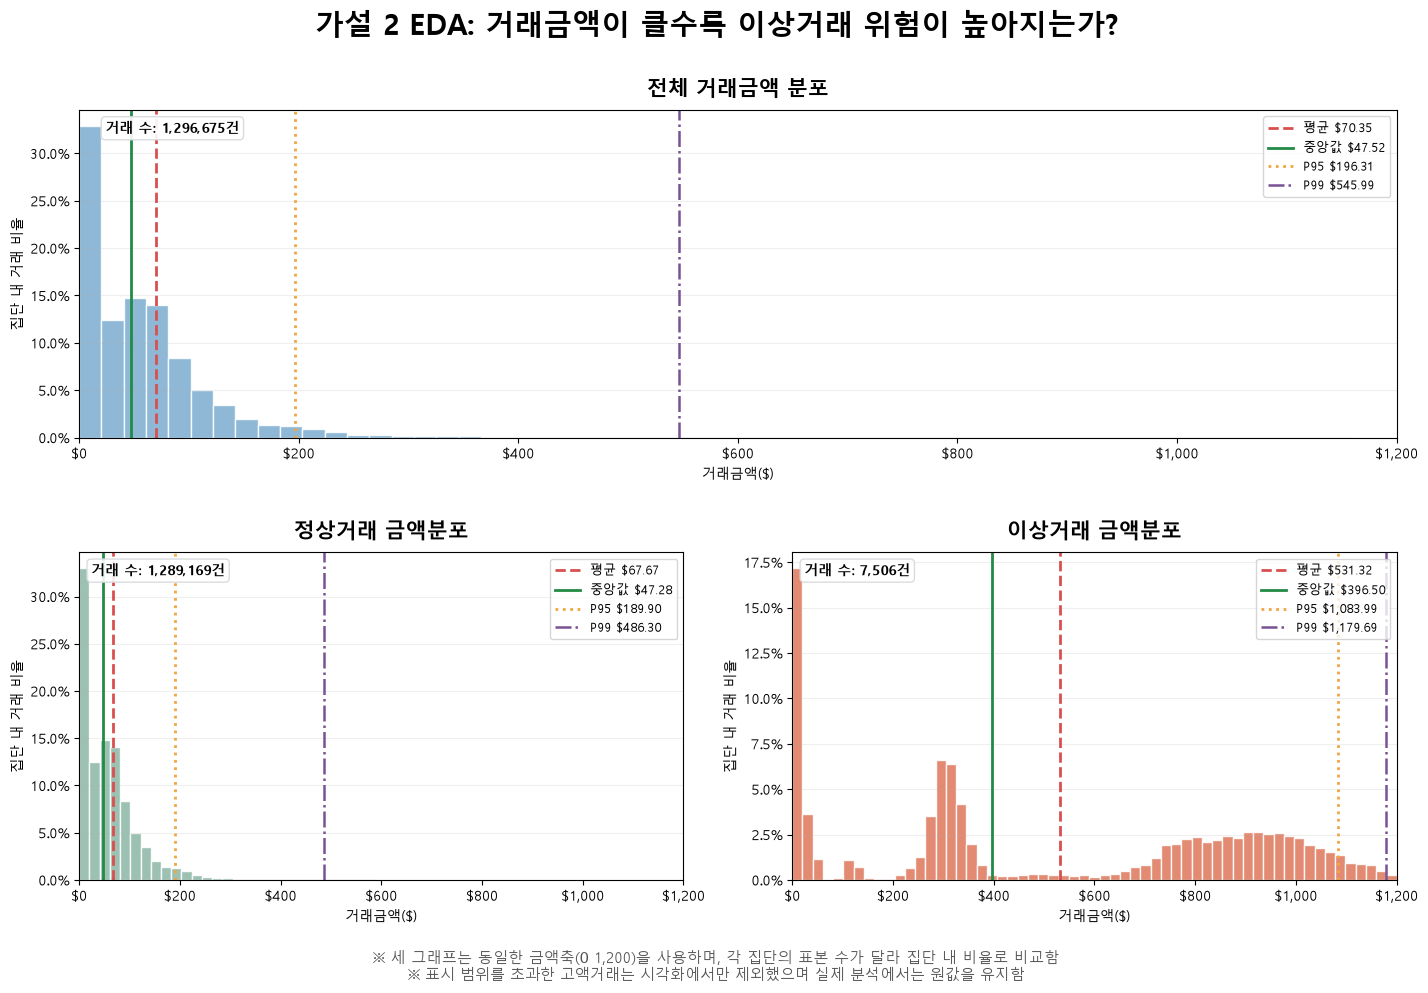


✅ 이미지 저장 완료
저장 경로: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\hypothesis2_amount_distribution_eda.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 분석 데이터 준비
# ============================================================

amount_all = df["amt"].dropna()
amount_normal = df.loc[df["is_fraud"] == 0, "amt"].dropna()
amount_abnormal = df.loc[df["is_fraud"] == 1, "amt"].dropna()

print(f"전체 거래: {len(amount_all):,}건")
print(f"정상거래: {len(amount_normal):,}건")
print(f"이상거래: {len(amount_abnormal):,}건")


# ============================================================
# 2. 집단별 통계 계산
# ============================================================

def amount_statistics(series, group_name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    return {
        "거래 구분": group_name,
        "거래 건수": len(series),
        "평균": series.mean(),
        "중앙값": series.median(),
        "표준편차": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "P95": series.quantile(0.95),
        "P99": series.quantile(0.99),
        "최댓값": series.max(),
        "왜도": series.skew()
    }


amount_summary = pd.DataFrame([
    amount_statistics(amount_all, "전체 거래"),
    amount_statistics(amount_normal, "정상거래"),
    amount_statistics(amount_abnormal, "이상거래")
])

display(
    amount_summary.style.format({
        "거래 건수": "{:,.0f}",
        "평균": "${:,.2f}",
        "중앙값": "${:,.2f}",
        "표준편차": "${:,.2f}",
        "Q1": "${:,.2f}",
        "Q3": "${:,.2f}",
        "IQR": "${:,.2f}",
        "P95": "${:,.2f}",
        "P99": "${:,.2f}",
        "최댓값": "${:,.2f}",
        "왜도": "{:,.2f}"
    })
)


# ============================================================
# 3. 시각화 공통 범위 결정
# ============================================================

# 정상·이상거래를 동일한 금액 축에서 비교하기 위해
# 각 집단 P99 중 큰 값을 시각화 상한으로 사용
visual_upper = max(
    amount_all.quantile(0.99),
    amount_normal.quantile(0.99),
    amount_abnormal.quantile(0.99)
)

# 보기 좋은 금액 단위로 올림
visual_upper = np.ceil(visual_upper / 100) * 100

# 모든 그래프에 동일한 구간 적용
bins = np.linspace(0, visual_upper, 60)

print(f"\n그래프 표시 범위: $0 ~ ${visual_upper:,.0f}")
print("※ 표시 범위를 초과한 거래는 시각화에서만 제외되며 실제 데이터에서는 유지됩니다.")


# ============================================================
# 4. 히스토그램 함수
# ============================================================

def draw_amount_histogram(
    ax,
    series,
    title,
    color,
    visual_upper,
    bins
):
    # 전체 집단에서 각 구간이 차지하는 비율
    weights = np.ones(len(series)) / len(series) * 100

    ax.hist(
        series,
        bins=bins,
        weights=weights,
        color=color,
        edgecolor="white",
        alpha=0.88
    )

    mean_value = series.mean()
    median_value = series.median()
    p95_value = series.quantile(0.95)
    p99_value = series.quantile(0.99)

    ax.axvline(
        mean_value,
        color="#D94F4F",
        linestyle="--",
        linewidth=2,
        label=f"평균 ${mean_value:,.2f}"
    )

    ax.axvline(
        median_value,
        color="#238B45",
        linestyle="-",
        linewidth=2,
        label=f"중앙값 ${median_value:,.2f}"
    )

    ax.axvline(
        p95_value,
        color="#F2A541",
        linestyle=":",
        linewidth=2,
        label=f"P95 ${p95_value:,.2f}"
    )

    # P99가 표시 범위 안에 있을 때만 표시
    if p99_value <= visual_upper:
        ax.axvline(
            p99_value,
            color="#7A5195",
            linestyle="-.",
            linewidth=1.8,
            label=f"P99 ${p99_value:,.2f}"
        )

    ax.set_xlim(0, visual_upper)

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("거래금액($)")
    ax.set_ylabel("집단 내 거래 비율")

    ax.xaxis.set_major_formatter(
        mtick.StrMethodFormatter("${x:,.0f}")
    )

    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=100, decimals=1)
    )

    ax.grid(axis="y", alpha=0.2)

    ax.legend(
        fontsize=9,
        loc="upper right",
        frameon=True
    )

    # 표본 수 표시
    ax.text(
        0.02,
        0.93,
        f"거래 수: {len(series):,}건",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#D5D8DC",
            alpha=0.9
        )
    )


# ============================================================
# 5. 발표용 통합 시각화
# ============================================================

fig = plt.figure(figsize=(17, 10))

grid = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.18
)

# 전체 거래
ax1 = fig.add_subplot(grid[0, :])

draw_amount_histogram(
    ax=ax1,
    series=amount_all,
    title="전체 거래금액 분포",
    color="#7FAFD1",
    visual_upper=visual_upper,
    bins=bins
)

# 정상거래
ax2 = fig.add_subplot(grid[1, 0])

draw_amount_histogram(
    ax=ax2,
    series=amount_normal,
    title="정상거래 금액분포",
    color="#8FB9A8",
    visual_upper=visual_upper,
    bins=bins
)

# 이상거래
ax3 = fig.add_subplot(grid[1, 1])

draw_amount_histogram(
    ax=ax3,
    series=amount_abnormal,
    title="이상거래 금액분포",
    color="#E07A5F",
    visual_upper=visual_upper,
    bins=bins
)

fig.suptitle(
    "가설 2 EDA: 거래금액이 클수록 이상거래 위험이 높아지는가?",
    fontsize=21,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.01,
    (
        f"※ 세 그래프는 동일한 금액축($0~${visual_upper:,.0f})을 사용하며, "
        "각 집단의 표본 수가 달라 집단 내 비율로 비교함\n"
        "※ 표시 범위를 초과한 고액거래는 시각화에서만 제외했으며 "
        "실제 분석에서는 원값을 유지함"
    ),
    ha="center",
    fontsize=11,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

OUTPUT_PATH = Path.cwd() / "hypothesis2_amount_distribution_eda.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ 이미지 저장 완료")
print("저장 경로:", OUTPUT_PATH)

데이터 크기: (1296675, 2)
count_30min 결측치: 0


,count_30min,transaction_count,abnormal_count,normal_count,transaction_share_pct,abnormal_rate_pct,risk_lift,ci_lower_pct,ci_upper_pct,sample_status
0,0,"206,282","2,762","203,520",15.9085%,1.3389%,2.31배,1.2902%,1.3895%,충분
1,1,"1,007,030","3,896","1,003,134",77.6625%,0.3869%,0.67배,0.3749%,0.3992%,충분
2,2,"78,081",717,"77,364",6.0216%,0.9183%,1.59배,0.8537%,0.9876%,충분
3,3,"4,939",115,"4,824",0.3809%,2.3284%,4.02배,1.9434%,2.7875%,충분
4,4,321,15,306,0.0248%,4.6729%,8.07배,2.8520%,7.5659%,주의
5,5,22,1,21,0.0017%,4.5455%,7.85배,0.8069%,21.7985%,표본 매우 적음


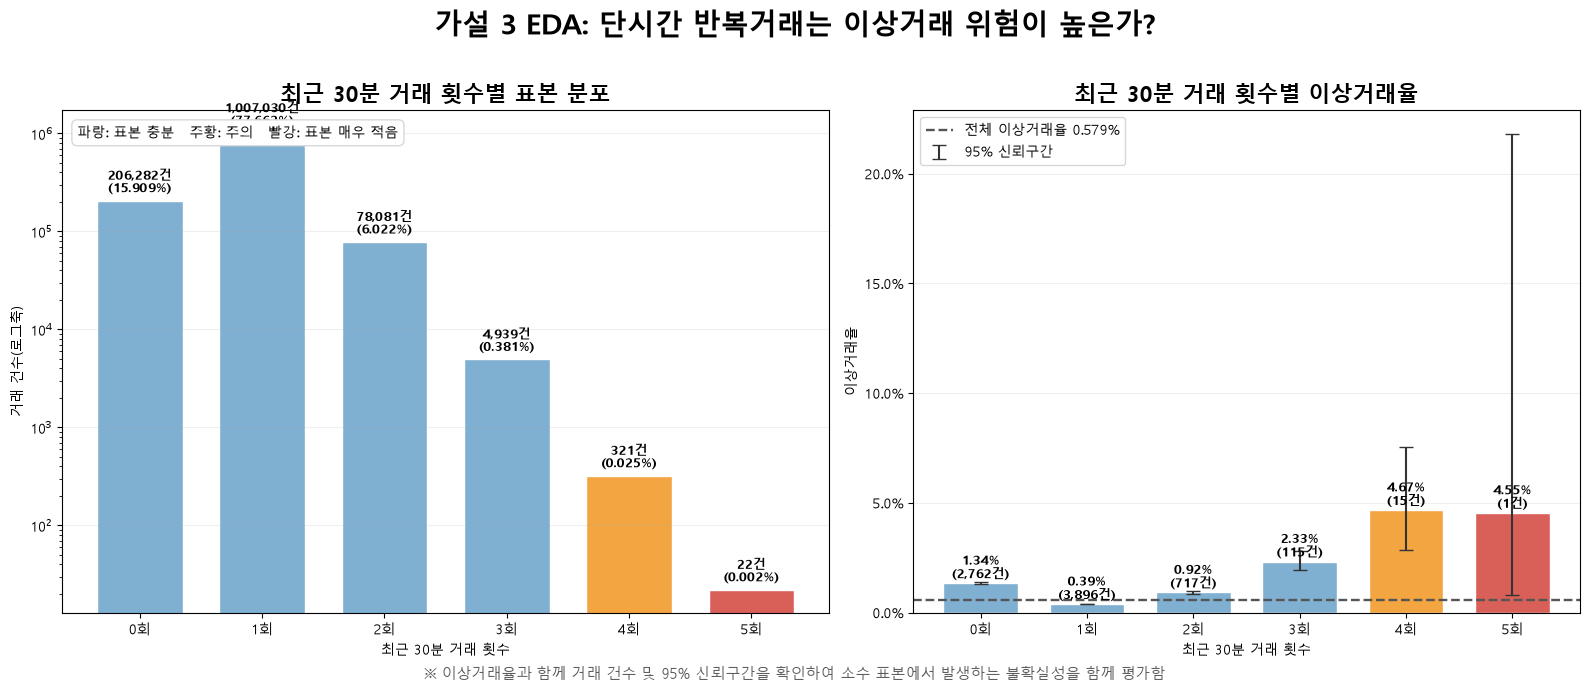


✅ 이미지 저장 완료
저장 경로: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\hypothesis3_count30min_eda.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 파생변수 포함 데이터 불러오기
# ============================================================

FEATURE_DATA_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data\fraud_full_features.csv"
)

feature_df = pd.read_csv(
    FEATURE_DATA_PATH,
    usecols=["count_30min", "is_fraud"],
    low_memory=False
)

print("데이터 크기:", feature_df.shape)
print("count_30min 결측치:", feature_df["count_30min"].isna().sum())


# ============================================================
# 2. Wilson 95% 신뢰구간 함수
# ============================================================

def wilson_interval(success, total, z=1.96):
    if total == 0:
        return np.nan, np.nan

    proportion = success / total
    denominator = 1 + (z ** 2 / total)

    center = (
        proportion
        + z ** 2 / (2 * total)
    ) / denominator

    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / total
            + z ** 2 / (4 * total ** 2)
        )
        / denominator
    )

    return center - margin, center + margin


# ============================================================
# 3. 횟수별 요약
# ============================================================

repeat_summary = (
    feature_df.groupby("count_30min")
    .agg(
        transaction_count=("is_fraud", "size"),
        abnormal_count=("is_fraud", "sum")
    )
    .reset_index()
    .sort_values("count_30min")
)

repeat_summary["normal_count"] = (
    repeat_summary["transaction_count"]
    - repeat_summary["abnormal_count"]
)

repeat_summary["transaction_share_pct"] = (
    repeat_summary["transaction_count"]
    / repeat_summary["transaction_count"].sum()
    * 100
)

repeat_summary["abnormal_rate_pct"] = (
    repeat_summary["abnormal_count"]
    / repeat_summary["transaction_count"]
    * 100
)

# 전체 이상거래율 대비 위험배수
overall_abnormal_rate = feature_df["is_fraud"].mean()

repeat_summary["risk_lift"] = (
    repeat_summary["abnormal_count"]
    / repeat_summary["transaction_count"]
    / overall_abnormal_rate
)

# 95% 신뢰구간
confidence_intervals = repeat_summary.apply(
    lambda row: wilson_interval(
        row["abnormal_count"],
        row["transaction_count"]
    ),
    axis=1
)

repeat_summary["ci_lower_pct"] = [
    interval[0] * 100
    for interval in confidence_intervals
]

repeat_summary["ci_upper_pct"] = [
    interval[1] * 100
    for interval in confidence_intervals
]

# 표본 수 경고
repeat_summary["sample_status"] = np.where(
    repeat_summary["transaction_count"] < 100,
    "표본 매우 적음",
    np.where(
        repeat_summary["transaction_count"] < 1000,
        "주의",
        "충분"
    )
)

display(
    repeat_summary.style.format({
        "transaction_count": "{:,.0f}",
        "abnormal_count": "{:,.0f}",
        "normal_count": "{:,.0f}",
        "transaction_share_pct": "{:.4f}%",
        "abnormal_rate_pct": "{:.4f}%",
        "risk_lift": "{:.2f}배",
        "ci_lower_pct": "{:.4f}%",
        "ci_upper_pct": "{:.4f}%"
    })
)


# ============================================================
# 4. 발표용 통합 시각화
# ============================================================

x = np.arange(len(repeat_summary))
x_labels = [
    f"{int(value)}회"
    for value in repeat_summary["count_30min"]
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6.5),
    gridspec_kw={"width_ratios": [1.15, 1]}
)

# ------------------------------------------------------------
# 왼쪽: 횟수별 거래 건수
# ------------------------------------------------------------

sample_colors = [
    "#D95F59" if count < 100
    else "#F2A541" if count < 1000
    else "#7FAFD1"
    for count in repeat_summary["transaction_count"]
]

bars1 = axes[0].bar(
    x,
    repeat_summary["transaction_count"],
    color=sample_colors,
    edgecolor="white",
    width=0.7
)

# 값 차이가 매우 크므로 로그축 사용
axes[0].set_yscale("log")

axes[0].set_title(
    "최근 30분 거래 횟수별 표본 분포",
    fontsize=16,
    fontweight="bold"
)
axes[0].set_xlabel("최근 30분 거래 횟수")
axes[0].set_ylabel("거래 건수(로그축)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].grid(axis="y", alpha=0.2)

# 거래 건수와 구성비 표시
for bar, count, share in zip(
    bars1,
    repeat_summary["transaction_count"],
    repeat_summary["transaction_share_pct"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f"{int(count):,}건\n({share:.3f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axes[0].text(
    0.02,
    0.97,
    "파랑: 표본 충분   주황: 주의   빨강: 표본 매우 적음",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="#D5D8DC"
    )
)


# ------------------------------------------------------------
# 오른쪽: 횟수별 이상거래율과 신뢰구간
# ------------------------------------------------------------

rates = repeat_summary["abnormal_rate_pct"].to_numpy()

lower_errors = (
    rates
    - repeat_summary["ci_lower_pct"].to_numpy()
)

upper_errors = (
    repeat_summary["ci_upper_pct"].to_numpy()
    - rates
)

bars2 = axes[1].bar(
    x,
    rates,
    color=sample_colors,
    edgecolor="white",
    width=0.7
)

axes[1].errorbar(
    x,
    rates,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    ecolor="#333333",
    capsize=5,
    linewidth=1.5,
    label="95% 신뢰구간"
)

# 전체 이상거래율 기준선
axes[1].axhline(
    overall_abnormal_rate * 100,
    color="#555555",
    linestyle="--",
    linewidth=1.7,
    label=f"전체 이상거래율 {overall_abnormal_rate * 100:.3f}%"
)

axes[1].set_title(
    "최근 30분 거래 횟수별 이상거래율",
    fontsize=16,
    fontweight="bold"
)
axes[1].set_xlabel("최근 30분 거래 횟수")
axes[1].set_ylabel("이상거래율")
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100)
)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(loc="upper left")

# 이상거래율과 이상거래 건수 표시
for bar, rate, abnormal_count in zip(
    bars2,
    repeat_summary["abnormal_rate_pct"],
    repeat_summary["abnormal_count"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(rates) * 0.025,
        f"{rate:.2f}%\n({int(abnormal_count):,}건)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )


fig.suptitle(
    "가설 3 EDA: 단시간 반복거래는 이상거래 위험이 높은가?",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    (
        "※ 이상거래율과 함께 거래 건수 및 95% 신뢰구간을 확인하여 "
        "소수 표본에서 발생하는 불확실성을 함께 평가함"
    ),
    ha="center",
    fontsize=11,
    color="#555555"
)

plt.tight_layout()

OUTPUT_PATH = Path.cwd() / "hypothesis3_count30min_eda.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ 이미지 저장 완료")
print("저장 경로:", OUTPUT_PATH)

분석 데이터 크기: (1296675, 7)
이상거래: 7,506건
전체 이상거래율: 0.5789%

Pearson 상관계수


,amt,amt_log1p,count_30min,is_night,is_fraud
amt,1.0000,0.4960,-0.0192,0.0324,0.2194
amt_log1p,0.4960,1.0000,0.0879,0.0459,0.1204
count_30min,-0.0192,0.0879,1.0000,-0.0492,-0.0231
is_night,0.0324,0.0459,-0.0492,1.0000,0.1102
is_fraud,0.2194,0.1204,-0.0231,0.1102,1.0000



Spearman 상관계수


,amt,amt_log1p,count_30min,is_night,is_fraud
amt,1.0000,1.0000,0.0941,0.0459,0.0879
amt_log1p,1.0000,1.0000,0.0941,0.0459,0.0879
count_30min,0.0941,0.0941,1.0000,-0.0511,-0.0280
is_night,0.0459,0.0459,-0.0511,1.0000,0.1102
is_fraud,0.0879,0.0879,-0.0280,0.1102,1.0000


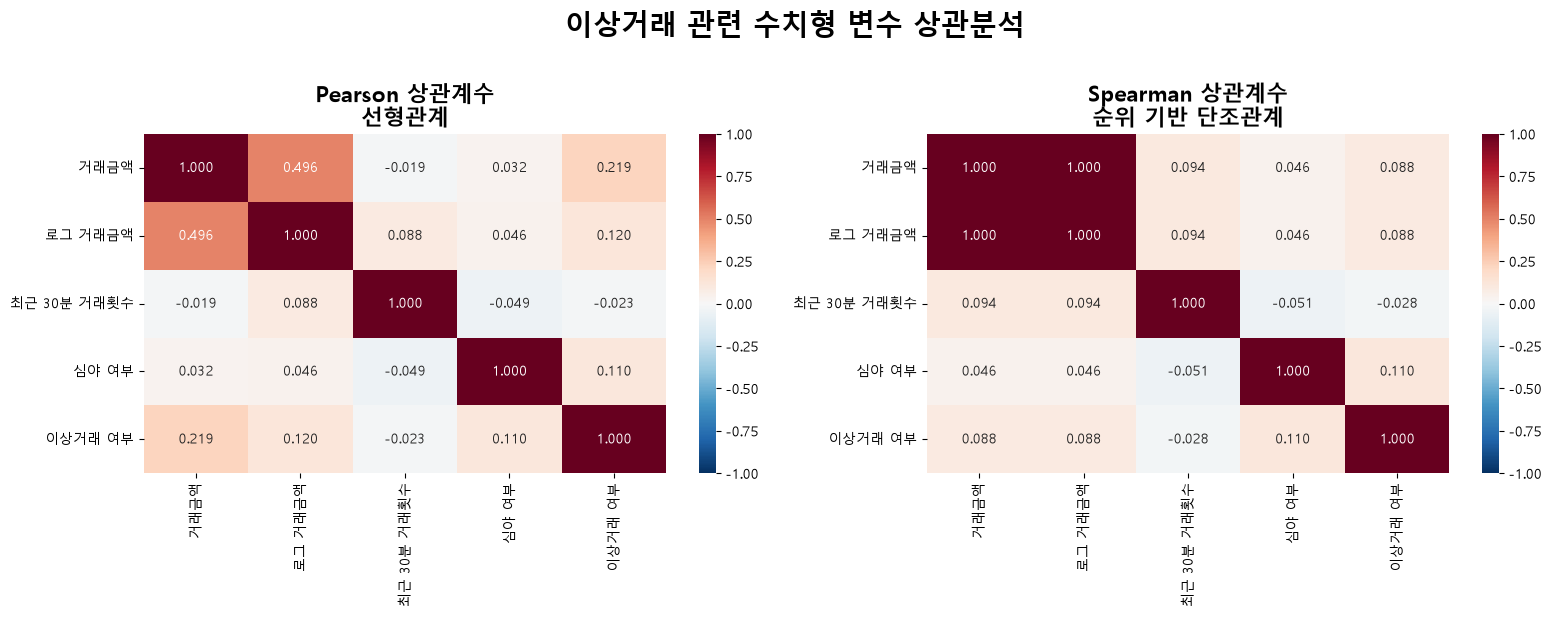


가설 1: 심야와 주간의 이상거래율 차이
심야 거래: 304,882건
심야 이상거래: 6,362건
심야 이상거래율: 2.0867%

주간 거래: 991,793건
주간 이상거래: 1,144건
주간 이상거래율: 0.1153%

이상거래율 차이: 1.9714%p
위험비: 18.09배
오즈비: 18.45
셔플 검정 p-value: 0.00001000
✅ 귀무가설 기각: 심야 이상거래율이 유의하게 높음

가설 2: 정상거래와 이상거래의 금액분포 차이
정상거래 중앙값: $47.28
이상거래 중앙값: $396.50
중앙값 차이: $349.23
Mann–Whitney U: 8,075,744,868
p-value: 0
Rank-biserial 효과크기: 0.6691
✅ 귀무가설 기각: 두 집단의 금액분포는 유의하게 다름

가설 3: 최근 30분 거래 횟수와 이상거래 여부
[관측빈도]


,정상거래,이상거래
count_30min_group,,
0회,203520,2762
1회,1003134,3896
2회,77364,717
3회 이상,5151,131


[기대빈도]


,정상거래,이상거래
count_30min_group,,
0회,205087.91,1194.09
1회,1001200.65,5829.35
2회,77629.02,451.98
3회 이상,5251.42,30.58


카이제곱 통계량: 3,203.7199
자유도: 3
p-value: 0
Cramér's V: 0.0497
최소 기대빈도: 30.58
✅ 모든 기대빈도가 5 이상으로 카이제곱 조건 충족
✅ 귀무가설 기각: 거래 횟수와 이상거래 여부는 관련 있음


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import (
    mannwhitneyu,
    chi2_contingency
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 분석 데이터 불러오기
# ============================================================

DATA_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data\fraud_full_features.csv"
)

analysis_df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "trans_date_trans_time",
        "amt",
        "count_30min",
        "is_fraud"
    ],
    low_memory=False
)

analysis_df["trans_date_trans_time"] = pd.to_datetime(
    analysis_df["trans_date_trans_time"],
    errors="coerce"
)

analysis_df["trans_hour"] = (
    analysis_df["trans_date_trans_time"].dt.hour
)

analysis_df["is_night"] = (
    (analysis_df["trans_hour"] >= 22)
    | (analysis_df["trans_hour"] < 4)
).astype(int)

# 거래금액의 극단값 영향을 비교하기 위한 로그값
analysis_df["amt_log1p"] = np.log1p(
    analysis_df["amt"]
)

print("분석 데이터 크기:", analysis_df.shape)
print("이상거래:", f"{analysis_df['is_fraud'].sum():,}건")
print(
    "전체 이상거래율:",
    f"{analysis_df['is_fraud'].mean() * 100:.4f}%"
)


# ============================================================
# 2. 상관분석
#    Pearson: 선형관계
#    Spearman: 순위 기반 단조관계
# ============================================================

correlation_columns = [
    "amt",
    "amt_log1p",
    "count_30min",
    "is_night",
    "is_fraud"
]

pearson_corr = (
    analysis_df[correlation_columns]
    .corr(method="pearson")
)

spearman_corr = (
    analysis_df[correlation_columns]
    .corr(method="spearman")
)

print("\n" + "=" * 80)
print("Pearson 상관계수")
print("=" * 80)
display(pearson_corr.round(4))

print("\n" + "=" * 80)
print("Spearman 상관계수")
print("=" * 80)
display(spearman_corr.round(4))


# ============================================================
# 3. 상관계수 시각화
# ============================================================

korean_labels = [
    "거래금액",
    "로그 거래금액",
    "최근 30분 거래횟수",
    "심야 여부",
    "이상거래 여부"
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=korean_labels,
    yticklabels=korean_labels,
    ax=axes[0]
)

axes[0].set_title(
    "Pearson 상관계수\n선형관계",
    fontsize=16,
    fontweight="bold"
)

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=korean_labels,
    yticklabels=korean_labels,
    ax=axes[1]
)

axes[1].set_title(
    "Spearman 상관계수\n순위 기반 단조관계",
    fontsize=16,
    fontweight="bold"
)

fig.suptitle(
    "이상거래 관련 수치형 변수 상관분석",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. 가설 1 검정
#    심야와 주간의 이상거래율 차이: 셔플 검정
#
#    실제 행 130만 개를 계속 섞으면 오래 걸리므로,
#    동일한 원리의 초기하분포 추출로 빠르게 수행
# ============================================================

night_mask = analysis_df["is_night"] == 1
day_mask = analysis_df["is_night"] == 0

night_total = int(night_mask.sum())
day_total = int(day_mask.sum())

night_abnormal = int(
    analysis_df.loc[night_mask, "is_fraud"].sum()
)

day_abnormal = int(
    analysis_df.loc[day_mask, "is_fraud"].sum()
)

night_rate = night_abnormal / night_total
day_rate = day_abnormal / day_total

observed_rate_diff = night_rate - day_rate

# 위험비
risk_ratio = night_rate / day_rate

# 오즈비
odds_ratio = (
    (night_abnormal / (night_total - night_abnormal))
    / (day_abnormal / (day_total - day_abnormal))
)

# 빠른 셔플 검정
rng = np.random.default_rng(42)

n_simulations = 100_000
total_count = len(analysis_df)
total_abnormal = int(analysis_df["is_fraud"].sum())

# 귀무가설 아래에서 심야 그룹에 배정될 이상거래 수
simulated_night_abnormal = rng.hypergeometric(
    ngood=total_abnormal,
    nbad=total_count - total_abnormal,
    nsample=night_total,
    size=n_simulations
)

simulated_night_rate = (
    simulated_night_abnormal / night_total
)

simulated_day_abnormal = (
    total_abnormal
    - simulated_night_abnormal
)

simulated_day_rate = (
    simulated_day_abnormal / day_total
)

simulated_rate_diff = (
    simulated_night_rate
    - simulated_day_rate
)

# 대립가설: 심야 이상거래율 > 주간 이상거래율
shuffle_p_value = (
    np.sum(simulated_rate_diff >= observed_rate_diff) + 1
) / (n_simulations + 1)

print("\n" + "=" * 80)
print("가설 1: 심야와 주간의 이상거래율 차이")
print("=" * 80)

print(f"심야 거래: {night_total:,}건")
print(f"심야 이상거래: {night_abnormal:,}건")
print(f"심야 이상거래율: {night_rate * 100:.4f}%")
print()
print(f"주간 거래: {day_total:,}건")
print(f"주간 이상거래: {day_abnormal:,}건")
print(f"주간 이상거래율: {day_rate * 100:.4f}%")
print()
print(
    "이상거래율 차이:",
    f"{observed_rate_diff * 100:.4f}%p"
)
print(f"위험비: {risk_ratio:.2f}배")
print(f"오즈비: {odds_ratio:.2f}")
print(f"셔플 검정 p-value: {shuffle_p_value:.8f}")

if shuffle_p_value < 0.05:
    print("✅ 귀무가설 기각: 심야 이상거래율이 유의하게 높음")
else:
    print("⚠️ 귀무가설을 기각하지 못함")


# ============================================================
# 5. 가설 2 검정
#    정상·이상거래 금액분포: Mann–Whitney U
# ============================================================

normal_amount = (
    analysis_df.loc[
        analysis_df["is_fraud"] == 0,
        "amt"
    ]
    .dropna()
)

abnormal_amount = (
    analysis_df.loc[
        analysis_df["is_fraud"] == 1,
        "amt"
    ]
    .dropna()
)

mw_result = mannwhitneyu(
    abnormal_amount,
    normal_amount,
    alternative="two-sided",
    method="asymptotic"
)

u_statistic = mw_result.statistic
mw_p_value = mw_result.pvalue

# Rank-biserial correlation
# 양수: 이상거래 금액이 정상거래보다 전반적으로 큼
rank_biserial = (
    2 * u_statistic
    / (len(abnormal_amount) * len(normal_amount))
    - 1
)

print("\n" + "=" * 80)
print("가설 2: 정상거래와 이상거래의 금액분포 차이")
print("=" * 80)

print(
    "정상거래 중앙값:",
    f"${normal_amount.median():,.2f}"
)
print(
    "이상거래 중앙값:",
    f"${abnormal_amount.median():,.2f}"
)
print(
    "중앙값 차이:",
    f"${abnormal_amount.median() - normal_amount.median():,.2f}"
)

print(f"Mann–Whitney U: {u_statistic:,.0f}")
print(f"p-value: {mw_p_value:.8g}")
print(
    "Rank-biserial 효과크기:",
    f"{rank_biserial:.4f}"
)

if mw_p_value < 0.05:
    print("✅ 귀무가설 기각: 두 집단의 금액분포는 유의하게 다름")
else:
    print("⚠️ 귀무가설을 기각하지 못함")


# ============================================================
# 6. 가설 3 검정
#    최근 30분 거래 횟수와 이상거래 여부: 카이제곱
#
#    4·5회는 표본이 너무 적으므로 검정에서는 3회 이상으로 통합
# ============================================================

analysis_df["count_30min_group"] = pd.cut(
    analysis_df["count_30min"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=["0회", "1회", "2회", "3회 이상"]
)

count_crosstab = pd.crosstab(
    analysis_df["count_30min_group"],
    analysis_df["is_fraud"]
)

count_crosstab.columns = [
    "정상거래",
    "이상거래"
]

chi2_statistic, chi2_p_value, degrees_freedom, expected = (
    chi2_contingency(count_crosstab)
)

expected_df = pd.DataFrame(
    expected,
    index=count_crosstab.index,
    columns=count_crosstab.columns
)

# Cramér's V
n = count_crosstab.to_numpy().sum()
min_dimension = min(count_crosstab.shape) - 1

cramers_v = np.sqrt(
    chi2_statistic
    / (n * min_dimension)
)

print("\n" + "=" * 80)
print("가설 3: 최근 30분 거래 횟수와 이상거래 여부")
print("=" * 80)

print("[관측빈도]")
display(count_crosstab)

print("[기대빈도]")
display(expected_df.round(2))

print(f"카이제곱 통계량: {chi2_statistic:,.4f}")
print(f"자유도: {degrees_freedom}")
print(f"p-value: {chi2_p_value:.8g}")
print(f"Cramér's V: {cramers_v:.4f}")
print(
    "최소 기대빈도:",
    f"{expected_df.to_numpy().min():.2f}"
)

if expected_df.to_numpy().min() >= 5:
    print("✅ 모든 기대빈도가 5 이상으로 카이제곱 조건 충족")
else:
    print("⚠️ 기대빈도 5 미만 구간 존재: 구간 재통합 필요")

if chi2_p_value < 0.05:
    print("✅ 귀무가설 기각: 거래 횟수와 이상거래 여부는 관련 있음")
else:
    print("⚠️ 귀무가설을 기각하지 못함")

In [11]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 435.7 kB/s eta 0:00:22
   ---------------------------------------- 0.1/9.6 MB 744.7 kB/s eta 0:00:13
    --------------------------------------- 0.2/9.6 MB 1.2 MB/s eta 0:00:08
   - -------------------------------------- 0.4/9.6 MB 2.1 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.6 MB 3.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.6 MB 4.5 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 5.4 MB/s eta 0:00:02
   -------- ------------------------------- 1.9/9.6 MB 5.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.5/9.6 MB 5.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.7/9.6 MB 5.7 MB/s eta 0:00:02
   ------------- ------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


회귀분석 데이터 크기: (1296675, 6)
이상거래: 7,506건
이상거래율: 0.5789%

업종 기준집단: gas_transport

[평소 대비 금액 구간]


,ratio_group,transaction_count,abnormal_count,abnormal_rate,abnormal_rate_pct
0,5배 미만,"1,243,226","1,996",0.001606,0.1606%
1,5~10배,"34,701","1,314",0.037866,3.7866%
2,10배 이상,"17,099","3,455",0.202059,20.2059%
3,과거이력 없음,"1,649",741,0.449363,44.9363%



[최근 24시간 고액거래 횟수 구간]


,recent_high_group,transaction_count,abnormal_count,abnormal_rate,abnormal_rate_pct
0,0회,"1,244,934","2,193",0.001762,0.1762%
1,1회,"45,913","1,694",0.036896,3.6896%
2,2회 이상,"5,828","3,619",0.620968,62.0968%



[고속이동 여부]


,high_speed,transaction_count,abnormal_count,abnormal_rate,abnormal_rate_pct
0,0,"1,139,777","6,142",0.005389,0.5389%
1,1,"156,898","1,364",0.008694,0.8694%



로지스틱 회귀 학습 시작
✅ 로지스틱 회귀 완료

다변량 로지스틱 회귀 핵심 결과


,variable_korean,odds_ratio,or_ci_lower,or_ci_upper,p_value,significance,interpretation
5,최근 24시간 고액거래 2회 이상,927.039배,770.911,1114.787,0,p<0.001,이상거래 오즈 증가
3,과거 정상거래 이력 없음,518.688배,397.562,676.717,0,p<0.001,이상거래 오즈 증가
2,평소 대비 10배 이상,342.855배,303.803,386.926,0,p<0.001,이상거래 오즈 증가
1,평소 대비 5~10배,43.263배,37.399,50.048,0,p<0.001,이상거래 오즈 증가
4,최근 24시간 고액거래 1회,21.580배,19.557,23.812,0,p<0.001,이상거래 오즈 증가
19,고속이동 100km/h 이상,2.008배,1.813,2.224,9.51475e-41,p<0.001,이상거래 오즈 증가


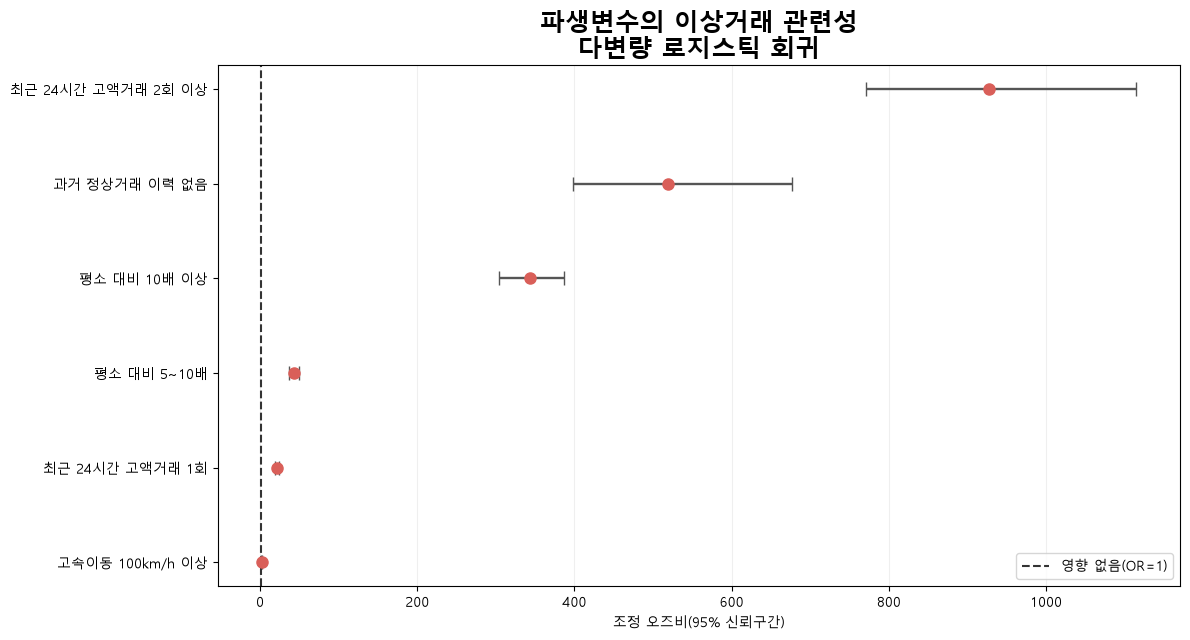


✅ 이미지 저장 완료
저장 경로: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\derived_features_logistic_odds_ratio.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 데이터 불러오기
# ============================================================

DATA_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data\fraud_full_features.csv"
)

reg_df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "cc_num",
        "category",
        "amt_to_prior_median_ratio",
        "recent_24h_high_amt_count",
        "high_speed",
        "is_fraud"
    ],
    low_memory=False
)

print("회귀분석 데이터 크기:", reg_df.shape)
print("이상거래:", f"{reg_df['is_fraud'].sum():,}건")
print(
    "이상거래율:",
    f"{reg_df['is_fraud'].mean() * 100:.4f}%"
)


# ============================================================
# 2. amt_to_prior_median_ratio 구간화
# ============================================================

ratio = reg_df["amt_to_prior_median_ratio"]

reg_df["ratio_group"] = np.select(
    [
        ratio.isna(),
        ratio < 5,
        (ratio >= 5) & (ratio < 10),
        ratio >= 10
    ],
    [
        "과거이력 없음",
        "5배 미만",
        "5~10배",
        "10배 이상"
    ],
    default="기타"
)

# 기준집단이 5배 미만이 되도록 순서 지정
reg_df["ratio_group"] = pd.Categorical(
    reg_df["ratio_group"],
    categories=[
        "5배 미만",
        "5~10배",
        "10배 이상",
        "과거이력 없음"
    ],
    ordered=False
)


# ============================================================
# 3. recent_24h_high_amt_count 구간화
# ============================================================

recent_count = reg_df["recent_24h_high_amt_count"]

reg_df["recent_high_group"] = np.select(
    [
        recent_count == 0,
        recent_count == 1,
        recent_count >= 2
    ],
    [
        "0회",
        "1회",
        "2회 이상"
    ],
    default="기타"
)

reg_df["recent_high_group"] = pd.Categorical(
    reg_df["recent_high_group"],
    categories=[
        "0회",
        "1회",
        "2회 이상"
    ],
    ordered=False
)


# ============================================================
# 4. 기타 변수 정리
# ============================================================

reg_df["high_speed"] = (
    reg_df["high_speed"]
    .fillna(0)
    .astype(int)
)

reg_df["category"] = (
    reg_df["category"]
    .fillna("unknown")
    .astype(str)
)

# 업종 기준집단
reference_category = "gas_transport"

if reference_category not in reg_df["category"].unique():
    reference_category = reg_df["category"].mode().iloc[0]

print("\n업종 기준집단:", reference_category)


# ============================================================
# 5. 구간별 기초 통계 확인
# ============================================================

def group_summary(data, column):
    result = (
        data.groupby(column, observed=True)
        .agg(
            transaction_count=("is_fraud", "size"),
            abnormal_count=("is_fraud", "sum"),
            abnormal_rate=("is_fraud", "mean")
        )
        .reset_index()
    )

    result["abnormal_rate_pct"] = (
        result["abnormal_rate"] * 100
    )

    return result


print("\n[평소 대비 금액 구간]")
display(
    group_summary(reg_df, "ratio_group").style.format({
        "transaction_count": "{:,.0f}",
        "abnormal_count": "{:,.0f}",
        "abnormal_rate": "{:.6f}",
        "abnormal_rate_pct": "{:.4f}%"
    })
)

print("\n[최근 24시간 고액거래 횟수 구간]")
display(
    group_summary(reg_df, "recent_high_group").style.format({
        "transaction_count": "{:,.0f}",
        "abnormal_count": "{:,.0f}",
        "abnormal_rate": "{:.6f}",
        "abnormal_rate_pct": "{:.4f}%"
    })
)

print("\n[고속이동 여부]")
display(
    group_summary(reg_df, "high_speed").style.format({
        "transaction_count": "{:,.0f}",
        "abnormal_count": "{:,.0f}",
        "abnormal_rate": "{:.6f}",
        "abnormal_rate_pct": "{:.4f}%"
    })
)


# ============================================================
# 6. 다변량 로지스틱 회귀
# ============================================================

formula = f"""
is_fraud
~ C(ratio_group, Treatment(reference='5배 미만'))
+ C(recent_high_group, Treatment(reference='0회'))
+ high_speed
+ C(category, Treatment(reference='{reference_category}'))
"""

print("\n로지스틱 회귀 학습 시작")

logistic_model = smf.glm(
    formula=formula,
    data=reg_df,
    family=sm.families.Binomial()
)

# 동일 카드의 반복 관측을 고려한 군집 강건 표준오차
logistic_result = logistic_model.fit(
    maxiter=100,
    cov_type="cluster",
    cov_kwds={
        "groups": reg_df["cc_num"]
    }
)

print("✅ 로지스틱 회귀 완료")


# ============================================================
# 7. 오즈비·신뢰구간·p-value 계산
# ============================================================

coefficient_table = pd.DataFrame({
    "coefficient": logistic_result.params,
    "std_error": logistic_result.bse,
    "p_value": logistic_result.pvalues
})

confidence_interval = logistic_result.conf_int()

coefficient_table["ci_lower"] = confidence_interval[0]
coefficient_table["ci_upper"] = confidence_interval[1]

# 로그 오즈 → 오즈비
coefficient_table["odds_ratio"] = np.exp(
    coefficient_table["coefficient"]
)

coefficient_table["or_ci_lower"] = np.exp(
    coefficient_table["ci_lower"]
)

coefficient_table["or_ci_upper"] = np.exp(
    coefficient_table["ci_upper"]
)

coefficient_table = (
    coefficient_table
    .reset_index()
    .rename(columns={"index": "variable"})
)


# ============================================================
# 8. 핵심 파생변수 결과만 추출
# ============================================================

key_results = coefficient_table[
    coefficient_table["variable"].str.contains(
        "ratio_group|recent_high_group|high_speed",
        regex=True
    )
].copy()

variable_name_map = {
    "C(ratio_group, Treatment(reference='5배 미만'))[T.5~10배]":
        "평소 대비 5~10배",

    "C(ratio_group, Treatment(reference='5배 미만'))[T.10배 이상]":
        "평소 대비 10배 이상",

    "C(ratio_group, Treatment(reference='5배 미만'))[T.과거이력 없음]":
        "과거 정상거래 이력 없음",

    "C(recent_high_group, Treatment(reference='0회'))[T.1회]":
        "최근 24시간 고액거래 1회",

    "C(recent_high_group, Treatment(reference='0회'))[T.2회 이상]":
        "최근 24시간 고액거래 2회 이상",

    "high_speed":
        "고속이동 100km/h 이상"
}

key_results["variable_korean"] = (
    key_results["variable"]
    .map(variable_name_map)
    .fillna(key_results["variable"])
)

key_results["significance"] = np.where(
    key_results["p_value"] < 0.001,
    "p<0.001",
    np.where(
        key_results["p_value"] < 0.05,
        "p<0.05",
        "유의하지 않음"
    )
)

key_results["interpretation"] = np.where(
    key_results["odds_ratio"] > 1,
    "이상거래 오즈 증가",
    "이상거래 오즈 감소"
)

key_results = key_results[
    [
        "variable_korean",
        "odds_ratio",
        "or_ci_lower",
        "or_ci_upper",
        "p_value",
        "significance",
        "interpretation"
    ]
].sort_values(
    "odds_ratio",
    ascending=False
)

print("\n" + "=" * 100)
print("다변량 로지스틱 회귀 핵심 결과")
print("=" * 100)

display(
    key_results.style.format({
        "odds_ratio": "{:.3f}배",
        "or_ci_lower": "{:.3f}",
        "or_ci_upper": "{:.3f}",
        "p_value": "{:.6g}"
    })
)


# ============================================================
# 9. 발표용 오즈비 시각화
# ============================================================

plot_df = key_results.sort_values(
    "odds_ratio",
    ascending=True
).copy()

y_position = np.arange(len(plot_df))

lower_error = (
    plot_df["odds_ratio"]
    - plot_df["or_ci_lower"]
)

upper_error = (
    plot_df["or_ci_upper"]
    - plot_df["odds_ratio"]
)

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.errorbar(
    plot_df["odds_ratio"],
    y_position,
    xerr=[
        lower_error,
        upper_error
    ],
    fmt="o",
    color="#D95F59",
    ecolor="#555555",
    elinewidth=1.7,
    capsize=5,
    markersize=8
)

# 오즈비 1 기준선
ax.axvline(
    1,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    label="영향 없음(OR=1)"
)

ax.set_yticks(y_position)
ax.set_yticklabels(
    plot_df["variable_korean"]
)

ax.set_xlabel("조정 오즈비(95% 신뢰구간)")
ax.set_title(
    "파생변수의 이상거래 관련성\n다변량 로지스틱 회귀",
    fontsize=18,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.2)
ax.legend()

plt.tight_layout()

OUTPUT_PATH = (
    Path.cwd()
    / "derived_features_logistic_odds_ratio.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ 이미지 저장 완료")
print("저장 경로:", OUTPUT_PATH)